In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# use the CAMB cosmology that generated the matter power spectra
import camb
from cosmology import Cosmology

# GLASS imports: matter, random fields, random points, galaxies
import glass.shells
import glass.fields
import glass.points
import glass.galaxies


# cosmology for the simulation
h = 0.7
Oc = 0.25
Ob = 0.05

# basic parameters of the simulation
nside = lmax = 9500

# set up CAMB parameters for matter angular power spectrum
pars = camb.set_params(H0=100*h, omch2=Oc*h**2, ombh2=Ob*h**2,
                       NonLinear=camb.model.NonLinear_both)

# get the cosmology from CAMB
#cosmo = Cosmology.from_camb(pars)

# shells of 200 Mpc in comoving distance spacing
#zb = glass.shells.distance_grid(cosmo, 0., 1., dx=200.)

# uniform matter weight function
#ws = glass.shells.tophat_windows(zb)

# load the angular matter power spectra previously computed with CAMB
#cls = np.load('cls.npy')

In [126]:
theoryinputdir = "/home/users/d/darwish/ACTdr6xDESy3/actxdes/data/spectra_mnu_takahashiactln_fit/"
index = -1
clgg = np.loadtxt(theoryinputdir+f'cl_gg_0_0.txt').T[1][:lmax]

In [157]:
from gaussiancl import gaussiancl
import numpy as np

alpha, alpha2 = shift, shift
gl, info, err, niter = gaussiancl(pixwin_2048**2*clgg[:n], 'lognormal', (alpha, alpha2), monopole = None)

In [168]:
out = cls_to_gcls(np.array([[pixwin_2048**2*clgg[:n]]]), np.array([[shift**2]]))

In [144]:
from fieldgen import trfutils


pixwin_2048 = hp.pixwin(2048, lmax = 10000)
n = pixwin_2048.size
out_cls = trfutils.cls_to_gcls(np.array([[pixwin_2048**2*clgg[:n]]]), np.array([[shift**2]]))[0,0]
out_cls

array([7.24751964e-06, 2.05380932e-05, 3.13290303e-05, ...,
       1.98844720e-08, 1.99869956e-08, 2.02019057e-08])

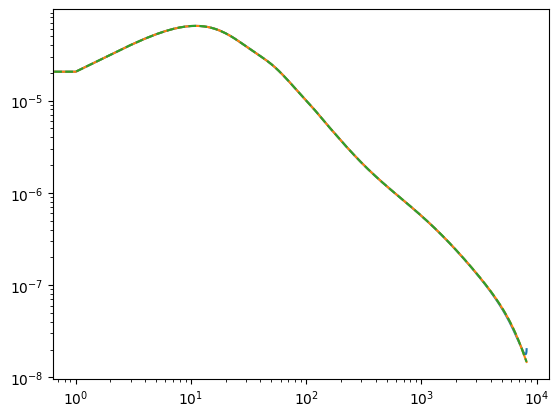

In [156]:
plt.loglog(out_cls)
plt.plot(gls)
plt.plot(gl, ls = "--")

In [45]:
shift = 1.089

In [118]:
# compute Gaussian cls for lognormal fields for 3 correlated shells
nside_out = 2048
gls = glass.fields.lognormal_gls([clgg], nside=nside_out, lmax=lmax, ncorr=1, shift = shift)

# generator for lognormal matter fields
matter = glass.fields.generate_lognormal(gls, nside_out, ncorr=1, shift = shift)
import numpy as np
rng = np.random.default_rng()
gaussian_field = glass.fields.generate_gaussian(gls, nside_out, ncorr=1, rng=rng)

In [119]:
for g in gaussian_field:
    gauss_real = g

In [132]:
for m in matter:
    m = m
    alm = shts.map2alm(m, lmax=3*nside_out-1)

In [49]:
import healpy as hp
from plancklens import shts

Using lenspyx alm2map


In [127]:
pixwin2048_special = hp.pixwin(2048)
nside_ = 2048
gls = glass.fields.lognormal_gls([clgg], nside=nside_, lmax=lmax, ncorr=1, shift = shift)[0]

In [ ]:
plt.loglog(hp.alm2cl(almG))


In [138]:
ll = 9000
almG = hp.synalm(gls) #8000, good number
real = shts.alm2map(almG.copy(), nside = nside_)
vargauss = np.var(real)
expmu = (0+shift)*np.exp(-vargauss*0.5)
real_lognormal = np.exp(real)
real_lognormal *= expmu 
real_lognormal -= shift
real_lognormal_lm = shts.map2alm(real_lognormal.copy(), 3*nside_-1)


In [135]:
ell = np.arange(len(gls))
var = np.sum((2*ell + 1)*gls)/(4*np.pi)

vargauss = var#np.var(gauss_real)
expmu = (0+shift)*np.exp(-vargauss*0.5)
real_lognormal_glass = np.exp(gauss_real)
real_lognormal_glass *= expmu 
real_lognormal_glass -= shift
real_lognormal_glass_lm = shts.map2alm(real_lognormal_glass.copy(), lmax = 3*nside_-1)

In [23]:
real_lognormal_2048 = hp.alm2map(real_lognormal_lm, nside = 2048) #lmax = 8000
real_lognormal_2048_lm = hp.map2alm(real_lognormal_2048)

#real_lognormal_glass_2048 = hp.alm2map(real_lognormal_glass_lm, nside = 2048) #lmax = 8000
#real_lognormal_glass_2048_lm = hp.map2alm(real_lognormal_glass_2048)

In [61]:
real_lognormal_2048_ud_grade = hp.ud_grade(real_lognormal, 2048)
real_lognormal_2048_ud_grade_lm = hp.map2alm(real_lognormal_2048_ud_grade)

In [136]:
from fieldgen import logutils
logutils.get_lambda_from_mappa(real_lognormal), logutils.get_lambda_from_mappa(real_lognormal_glass), logutils.get_lambda_from_mappa(real_lognormal_2048), logutils.get_lambda_from_mappa(real_lognormal_2048_ud_grade)

(1.0900970276696698,
 1.0930276637799232,
 1.2766001186977467,
 1.0892921536035884)

In [10]:
pixwin = hp.pixwin(nside_)
pixwin2048 = hp.pixwin(2048)
pixwin4096_2048 = hp.pixwin(4096, lmax = 2048*3-1)

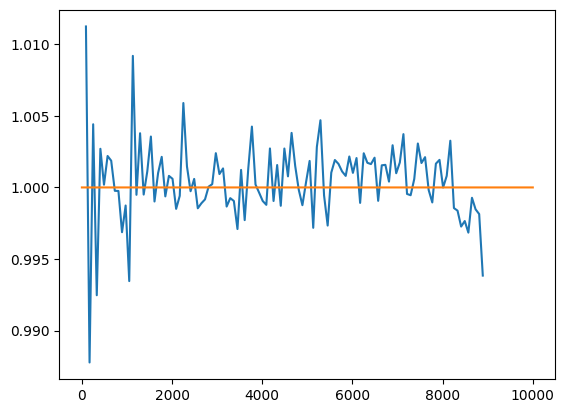

In [137]:
#plt.loglog(hp.alm2cl(real_lognormal_lm)/pixwin**2, label = "lognormal")
#plt.plot(clgg)


centst, a = fgutils.simple_binning(hp.alm2cl(real_lognormal_lm)/pixwin**2, bin_edges)
plt.plot(centst, a/dt)

plt.plot(clgg*0+1.)

In [98]:
real_lognormal_glass_2048 = hp.alm2map(real_lognormal_lm, nside = 2048, lmax = ll)

In [99]:
real_lognormal_glass_2048_lm = hp.map2alm(real_lognormal_glass_2048)

In [100]:
from fieldgen import logutils
logutils.get_lambda_from_mappa(real_lognormal), logutils.get_lambda_from_mappa(real_lognormal_glass_2048)

(1.0897923155921398, 1.210328878836629)

In [117]:
vargauss = np.var(gauss_real)
expmu = (0+shift)*np.exp(-vargauss*0.5)
real_lognormal_glass = np.exp(gauss_real)
real_lognormal_glass *= expmu 
real_lognormal_glass -= shift
real_lognormal_glass_lm = hp.map2alm(real_lognormal_glass)#, lmax = lmax)

In [108]:
from fieldgen import logutils

logutils.get_lambda_from_mappa(real_lognormal_glass)#, logutils.get_lambda_from_mappa(real_lognormal_glass_2048)


1.0888736073383738

In [109]:
for m in matter:
    alm = hp.map2alm(m)

In [111]:
logutils.get_lambda_from_mappa(m), logutils.get_lambda_from_mappa(real_lognormal_glass)

(1.089677049392949, 1.0888736073383738)

In [128]:
nside_ = 4096
lmax = hp.Alm.getlmax(real_lognormal_glass_lm.size)
pixwin = hp.pixwin(nside_, lmax = lmax)
real_lognormal_glass_2048 = hp.alm2map(real_lognormal_glass_lm, nside = 2048)#, lmax = hp.Alm.getlmax(real_lognormal_glass_lm.size))
real_lognormal_glass_2048_lm = hp.map2alm(real_lognormal_glass_2048)

(0.99, 1.01)

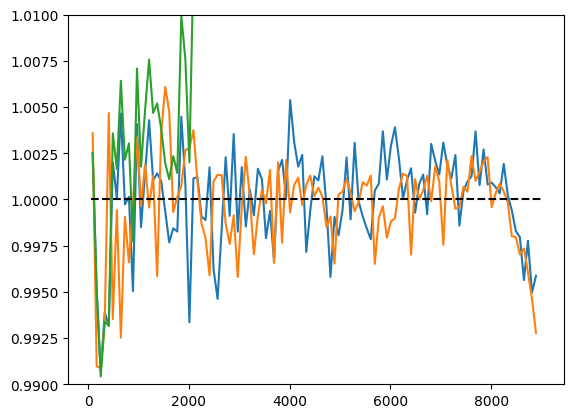

In [130]:
from fieldgen import utils as fgutils

bin_edges = np.arange(50, 9000, 80)
theory = clgg
centst, dt = fgutils.simple_binning(theory, bin_edges)

nside_ = 4096
lmax = hp.Alm.getlmax(real_lognormal_glass_lm.size)
pixwin =hp.pixwin(nside_, lmax = lmax)
xx = hp.alm2cl(real_lognormal_glass_lm)/pixwin**2
centst, a = fgutils.simple_binning(xx, bin_edges)
plt.plot(centst, a/dt)


xx = hp.alm2cl(alm)/pixwin**2
centst, a = fgutils.simple_binning(xx, bin_edges)
plt.plot(centst, a/dt)


pixwin = hp.pixwin(2048, lmax = hp.Alm.getlmax(real_lognormal_glass_2048_lm.size))
centst, a = fgutils.simple_binning(hp.alm2cl(real_lognormal_glass_2048_lm), bin_edges)
plt.plot(centst, a/dt)

plt.hlines(1, 50, 9000, color='k', linestyle='--')

plt.ylim(0.99, 1.01)

In [27]:
import healpy as hp

In [28]:
for m in matter:
    alm = hp.map2alm(m, lmax = 3*nside-1)

/home/users/d/darwish/fieldgen/fieldgen/utils.py:116: RuntimeWarning: invalid value encountered in true_divide
  cl = cl[0] / sums[0]


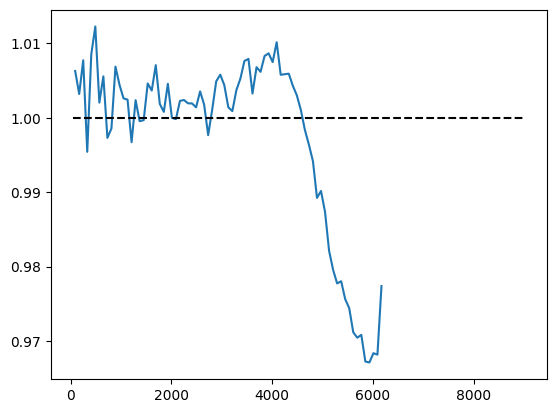

In [32]:
#plt.loglog(hp.alm2cl(alm))
#plt.plot(clgg)

from fieldgen import utils as fgutils

bin_edges = np.arange(50, 9000, 80)
theory = clgg
centst, dt = fgutils.simple_binning(theory, bin_edges)

pixwin = hp.pixwin(nside)
centst, a = fgutils.simple_binning(hp.alm2cl(alm)/pixwin**2, bin_edges)

plt.plot(centst, a/dt)

plt.hlines(1, 50, 9000, color='k', linestyle='--')